In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import time
import os
import psutil

overall_start = time.time()
process = psutil.Process(os.getpid())

print("Loading fixed genotypes (310 samples, 50k SNPs)...")
genotypes = pd.read_csv('manual_gwas_input_final.raw', sep=r'\s+', low_memory=False)

y = genotypes.iloc[:, 5].values
y_centered = y - np.mean(y)

snp_names_raw = genotypes.columns[6:]
X = genotypes.iloc[:, 6:].values

X[np.isnan(X)] = np.take(np.nanmean(X, axis=0), np.where(np.isnan(X))[1])
X_centered = X - np.mean(X, axis=0)

print(f"Matrix dimensions: {X.shape[0]} samples x {X.shape[1]} SNPs")

math_start = time.time()

numerator = np.dot(X_centered.T, y_centered)
denominator = np.sum(X_centered**2, axis=0)
denominator[denominator == 0] = np.nan
betas = numerator / denominator

y_pred = X_centered * betas
residuals = y_centered[:, np.newaxis] - y_pred
rss = np.sum(residuals**2, axis=0)

n = X.shape[0]
se = np.sqrt(rss / (n - 2)) / np.sqrt(denominator)
p_vals = stats.t.sf(np.abs(betas/se), n - 2) * 2

math_end = time.time()
results = pd.DataFrame({
    'SNP': [name.split('_')[0] for name in snp_names_raw],
    'BETA': betas, 'P': p_vals
}).dropna()

results.to_csv('manual_gwas_results_final.csv', index=False)

overall_end = time.time()
mem_usage = process.memory_info().rss / (1024 * 1024) # Convert to MB

print("\n" + "="*30)
print("GWAS BENCHMARK REPORT")
print("="*30)
print(f"Execution Time (Math only):   {math_end - math_start:.4f} seconds")
print(f"Execution Time (Total):       {overall_end - overall_start:.4f} seconds")
print(f"Peak Memory Usage:            {mem_usage:.2f} MB")
print(f"Matrix X theoretical size:    {X.nbytes / (1024*1024):.2f} MB")
print("="*30)
print("Done! Results saved for all 310 samples.")

Loading fixed genotypes (310 samples, 50k SNPs)...
Matrix dimensions: 310 samples x 50000 SNPs

GWAS BENCHMARK REPORT
Execution Time (Math only):   1.1855 seconds
Execution Time (Total):       7.1267 seconds
Peak Memory Usage:            1445.91 MB
Matrix X theoretical size:    118.26 MB
Done! Results saved for all 310 samples.


In [ ]:
import pandas as pd
import numpy as np

results = pd.read_csv('manual_gwas_results_final.csv')
causal_list = pd.read_csv('causal.snplist', header=None)[0].values

causal_hits = results[results['SNP'].isin(causal_list)].copy()

causal_hits['-log10P'] = -np.log10(causal_hits['P'])

print(f"Found {len(causal_hits)} out of 20 causal SNPs in the results.")
print("\nTop Causal SNPs recovered:")
print(causal_hits.sort_values(by='P'))

Found 20 out of 20 causal SNPs in the results.

Top Causal SNPs recovered:
               SNP       BETA             P    -log10P
7496     rs6518997  11.418036  5.805937e-48  47.236128
7730     rs6000605   7.248225  2.174785e-26  25.662584
15077     rs137193   4.492807  7.558433e-14  13.121568
26025     rs361845  -4.322003  7.145381e-13  12.145975
14856     rs134696  -3.776887  2.500671e-11  10.601944
30208   rs11570726   7.676667  1.094453e-09   8.960803
41905     rs801705   7.943831  2.143942e-09   8.668787
21234   rs73884225   6.609338  4.617748e-09   8.335570
15446    rs2283825   4.625963  8.736412e-08   7.058667
37407     rs139075   3.173083  9.944541e-06   5.002415
12701    rs5751937  -2.503014  2.400993e-04   3.619609
43119     rs130859   3.939036  1.224711e-03   2.911966
34308     rs133379  -2.559805  2.352674e-03   2.628438
9715    rs12159358  -2.744633  3.456902e-03   2.461313
40058   rs13054344  -2.599673  1.619786e-02   1.790542
36045   rs13053653  -0.729837  2.870529e-01  

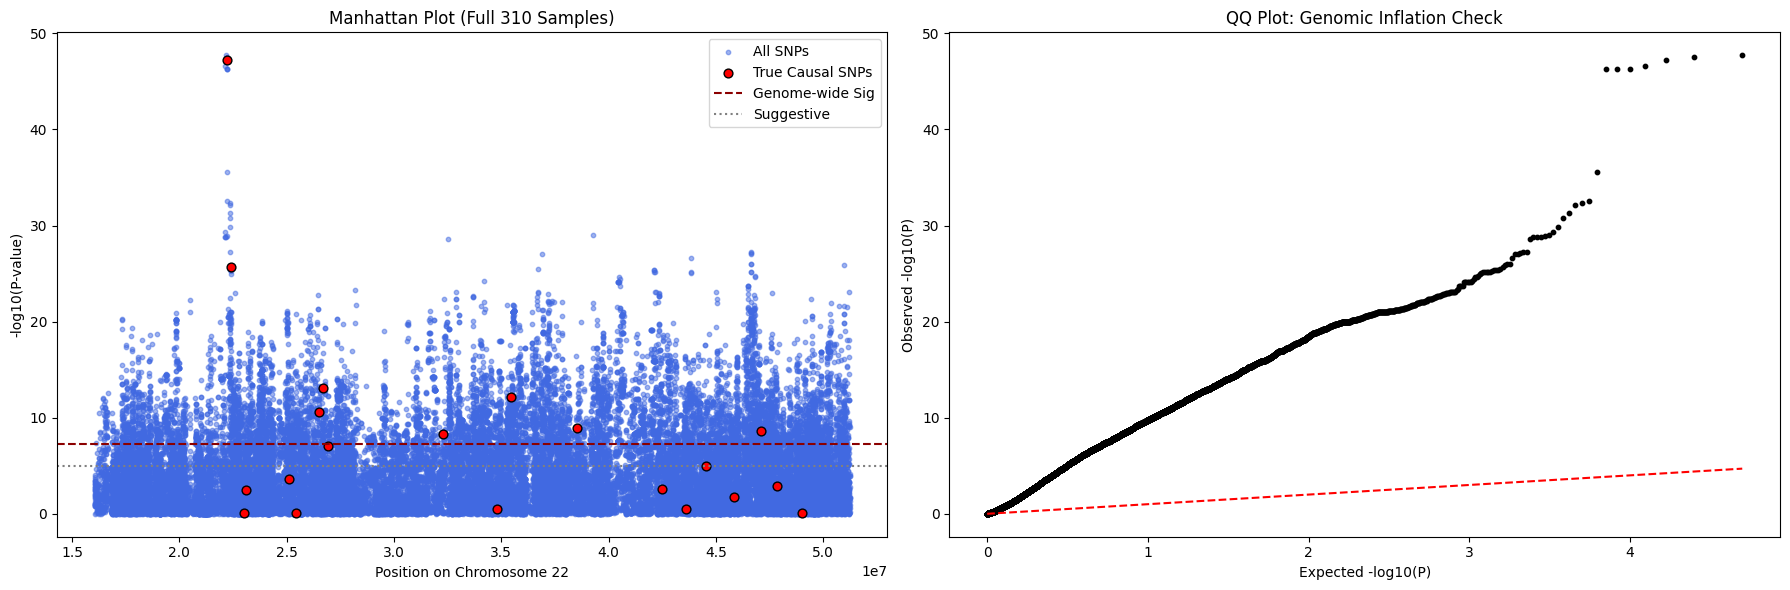

Genomic Inflation Factor (Lambda GC): 21.833


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

bim = pd.read_csv('chr22_with_pheno.bim', sep=r'\s+', header=None,
                 names=['CHR', 'SNP', 'CM', 'POS', 'A1', 'A2'])

df = pd.merge(results, bim[['SNP', 'POS']], on='SNP')
df['-log10P'] = -np.log10(df['P'])
df = df.sort_values('POS')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.scatter(df['POS'], df['-log10P'], c='royalblue', s=10, alpha=0.5, label='All SNPs')

causal_df = df[df['SNP'].isin(causal_list)]
ax1.scatter(causal_df['POS'], causal_df['-log10P'], c='red', s=40, label='True Causal SNPs', edgecolors='black')

ax1.axhline(y=-np.log10(5e-8), color='darkred', linestyle='--', label='Genome-wide Sig')
ax1.axhline(y=-np.log10(1e-5), color='gray', linestyle=':', label='Suggestive')

ax1.set_title('Manhattan Plot (Full 310 Samples)')
ax1.set_xlabel('Position on Chromosome 22')
ax1.set_ylabel('-log10(P-value)')
ax1.legend()

observed = np.sort(df['P'])
expected = np.arange(1, len(observed) + 1) / (len(observed) + 1)

ax2.scatter(-np.log10(expected), -np.log10(observed), c='black', s=10)
max_val = np.max(-np.log10(expected))
ax2.plot([0, max_val], [0, max_val], color='red', linestyle='--')

ax2.set_title('QQ Plot: Genomic Inflation Check')
ax2.set_xlabel('Expected -log10(P)')
ax2.set_ylabel('Observed -log10(P)')

plt.tight_layout()
plt.show()

from scipy import stats
chisq = stats.chi2.ppf(1 - df['P'], 1)
lambda_gc = np.median(chisq) / 0.454
print(f"Genomic Inflation Factor (Lambda GC): {lambda_gc:.3f}")

In [ ]:
chisq = stats.chi2.ppf(1 - results['P'], 1)
lambda_gc = np.median(chisq) / 0.454

print(f"Genomic Inflation Factor (Lambda GC): {lambda_gc:.3f}")

if lambda_gc > 1.1:
    print("WARNING: Severe population inflation detected. Your 'hits' may be false positives.")
else:
    print("The study is well-calibrated.")

Genomic Inflation Factor (Lambda GC): 21.833


In [ ]:
false_positives = results[(~results['SNP'].isin(causal_list)) & (results['P'] < 5e-8)]
print(f"Number of False Positives: {len(false_positives)}")

Number of False Positives: 9384


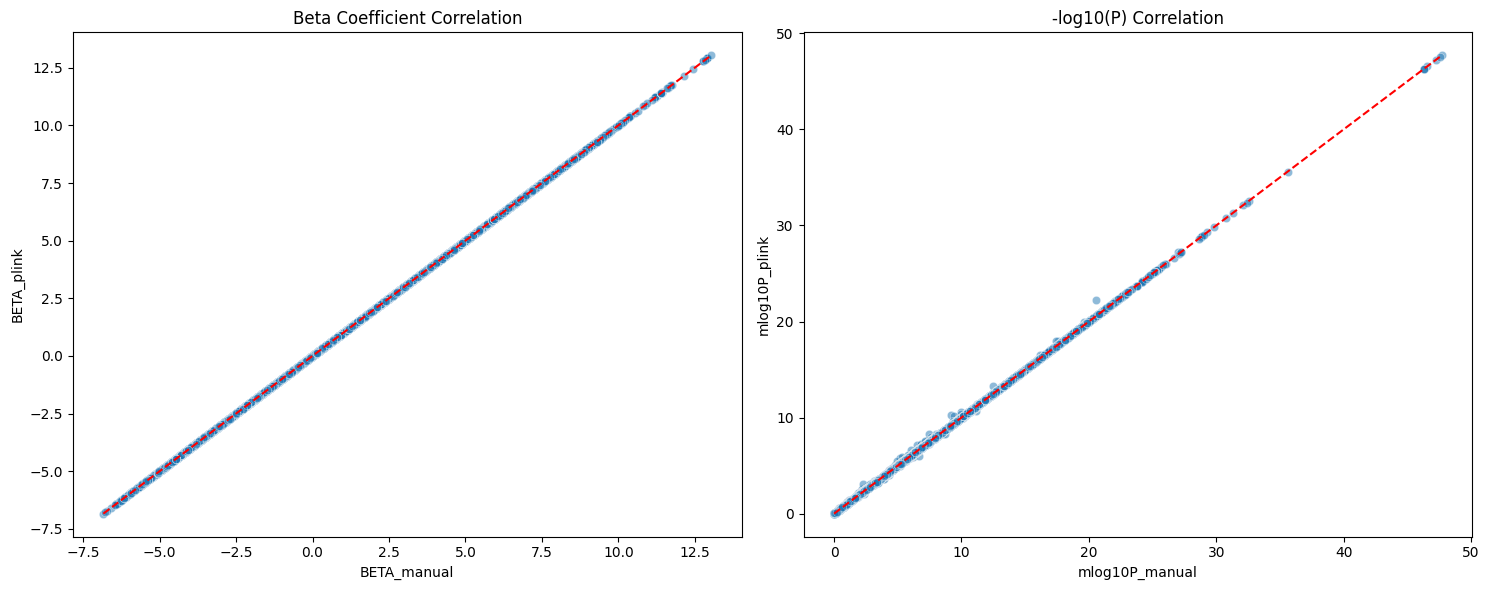

P-value Correlation: 0.999995


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

manual = pd.read_csv('manual_gwas_results_final.csv')

plink = pd.read_csv('plink_naive_results.assoc.linear', sep=r'\s+')
plink = plink[plink['TEST'] == 'ADD']

merged = pd.merge(manual, plink, on='SNP', suffixes=('_manual', '_plink'))

merged['mlog10P_manual'] = -np.log10(merged['P_manual'])
merged['mlog10P_plink'] = -np.log10(merged['P_plink'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=merged, x='BETA_manual', y='BETA_plink', ax=ax1, alpha=0.5)
ax1.plot([merged['BETA_manual'].min(), merged['BETA_manual'].max()],
         [merged['BETA_manual'].min(), merged['BETA_manual'].max()], 'r--')
ax1.set_title('Beta Coefficient Correlation')

sns.scatterplot(data=merged, x='mlog10P_manual', y='mlog10P_plink', ax=ax2, alpha=0.5)
ax2.plot([0, merged['mlog10P_manual'].max()], [0, merged['mlog10P_manual'].max()], 'r--')
ax2.set_title('-log10(P) Correlation')

plt.tight_layout()
plt.show()

correlation = merged['P_manual'].corr(merged['P_plink'])
print(f"P-value Correlation: {correlation:.6f}")

In [ ]:
import pandas as pd

plink_results = pd.read_csv('plink_naive_results.assoc.linear', sep=r'\s+')

plink_clean = plink_results[plink_results['TEST'] == 'ADD'].copy()

plink_sorted = plink_clean.sort_values(by='P', ascending=True)

print("Top 20 Most Significant SNPs (Naive GWAS):")
print(plink_sorted[['SNP', 'BETA', 'STAT', 'P']].head(20))

plink_sorted.to_csv('plink_naive_sorted.csv', index=False)

Top 20 Most Significant SNPs (Naive GWAS):
               SNP    BETA   STAT             P
7472     rs5999704  11.430  17.59  1.892000e-48
7504    rs73386262  11.260  17.55  2.805000e-48
7496     rs6518997  11.420  17.47  5.806000e-48
7434    rs60882067  11.200  17.29  2.730000e-47
7510     rs5999891  11.210  17.23  4.742000e-47
7509     rs5999887  11.210  17.23  4.742000e-47
7508     rs5999880  11.210  17.23  4.742000e-47
7488   rs532771093  12.150  14.41  2.431000e-36
7519     rs6519019  11.090  13.59  2.707000e-33
7700      rs458823   7.011  13.55  4.070000e-33
7698      rs462426   6.984  13.47  7.936000e-33
7699      rs460715   6.952  13.25  5.184000e-32
7688   rs111423778   6.337  13.11  1.646000e-31
7718     rs1441033   7.597  12.86  1.399000e-30
7407     rs3810607  12.910  12.70  5.272000e-30
31000   rs12159761   5.872  12.63  9.554000e-30
7511   rs112441221  13.040  12.60  1.208000e-29
7415     rs8138018  12.910  12.56  1.670000e-29
7432     rs7286970  12.910  12.56  1.670000e-